In [ ]:
# [Cell 0] 구글 코랩 환경 필수 패키지 설치
# 실행 후 런타임 재시작이 필요할 수 있습니다.
!pip install -q qiskit qiskit-aer scipy numpy matplotlib seaborn

import numpy as np
import scipy.linalg as la
from scipy.optimize import linear_sum_assignment
import matplotlib.pyplot as plt
import seaborn as sns

# Qiskit 핵심 모듈 임포트
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector, partial_trace, state_fidelity
from qiskit.circuit.library import RXGate, RYGate, RZGate, CXGate

print("✔ 모든 양자 컴퓨팅 및 시각화 라이브러리가 성공적으로 로드되었습니다.")

✔ 모든 양자 컴퓨팅 및 시각화 라이브러리가 성공적으로 로드되었습니다.


In [ ]:
# [Cell 1] Problem 1-(a): Build the initial target ensemble S_0

# Problem requirement:
# - Use N = 50~100 samples.
# - Use sigma = 0.10 by default.
# - If N or sigma is changed, state the value explicitly and explain why.
PROBLEM_1A_N = 80
PROBLEM_1A_SIGMA = 0.10
PROBLEM_1A_SEED = 2026
PROBLEM_1A_N_REASON = "N=80 is inside the requested 50~100 range and balances statistics with runtime."
PROBLEM_1A_SIGMA_REASON = "Use the problem default sigma=0.10."


def validate_problem_1a_config(
    num_samples: int,
    sigma: float,
    n_reason: str,
    sigma_reason: str,
) -> None:
    """Validate the Problem 1-(a) N and sigma choices."""
    if num_samples <= 0:
        raise ValueError("N must be positive.")
    if sigma <= 0:
        raise ValueError("sigma must be positive.")
    if not (50 <= num_samples <= 100) and not n_reason.strip():
        raise ValueError("N is outside the requested 50~100 range. State the reason in PROBLEM_1A_N_REASON.")
    if not np.isclose(sigma, 0.10) and not sigma_reason.strip():
        raise ValueError("sigma differs from 0.10. State the reason in PROBLEM_1A_SIGMA_REASON.")


def generate_initial_ensemble(
    num_samples: int = PROBLEM_1A_N,
    sigma: float = PROBLEM_1A_SIGMA,
    seed: int = PROBLEM_1A_SEED,
) -> list[Statevector]:
    """
    Generate the two-qubit target ensemble S_0 clustered around |00>.

    For each sample and each qubit q=0,1, draw independent angles
    delta_y, delta_z ~ Normal(0, sigma^2), then apply Ry(delta_y)
    followed by Rz(delta_z), matching the Problem 1-(a) construction.
    """
    validate_problem_1a_config(
        num_samples=num_samples,
        sigma=sigma,
        n_reason=PROBLEM_1A_N_REASON,
        sigma_reason=PROBLEM_1A_SIGMA_REASON,
    )

    rng = np.random.default_rng(seed)
    ensemble = []

    for _ in range(num_samples):
        qc = QuantumCircuit(2)

        for q in range(2):
            delta_y = rng.normal(loc=0.0, scale=sigma)
            delta_z = rng.normal(loc=0.0, scale=sigma)
            qc.ry(delta_y, q)
            qc.rz(delta_z, q)

        ensemble.append(Statevector.from_instruction(qc))

    return ensemble


# Generate S_0 with the explicit Problem 1-(a) configuration above.
S_0 = generate_initial_ensemble()

# Report sanity checks required for the target ensemble.
fidelity_to_00 = np.array([np.abs(state.data[0]) ** 2 for state in S_0])
norms = np.array([np.linalg.norm(state.data) for state in S_0])

print("Problem 1-(a) target ensemble S_0 generated")
print(f"  - N: {PROBLEM_1A_N}")
print(f"  - sigma: {PROBLEM_1A_SIGMA}")
print(f"  - seed: {PROBLEM_1A_SEED}")
print(f"  - N reason: {PROBLEM_1A_N_REASON}")
print(f"  - sigma reason: {PROBLEM_1A_SIGMA_REASON}")
print(f"  - state norm range: {norms.min():.6f} ~ {norms.max():.6f}")
print(f"  - mean fidelity to |00>: {fidelity_to_00.mean():.6f}")
print(f"  - example statevector[0]: {S_0[0].data}")


In [ ]:
# [Cell 2] Problem 1-(b): 양자 앙상블 간의 거리 측정 지표 함수 정의

def compute_pairwise_fidelity_matrix(ens1: list[Statevector], ens2: list[Statevector]) -> np.ndarray:
    """두 앙상블 간의 모든 상태 조합에 대해 Fidelity F(psi, phi) = |<psi|phi>|^2 행렬을 계산합니다."""
    N1, N2 = len(ens1), len(ens2)
    F_matrix = np.zeros((N1, N2))
    for i in range(N1):
        for j in range(N2):
            # state_fidelity 함수는 두 상태 간의 내적 절대값 제곱을 반환함
            F_matrix[i, j] = state_fidelity(ens1[i], ens2[j])
    return F_matrix

def compute_mmd_distance(ens_A: list[Statevector], ens_B: list[Statevector]) -> float:
    """
    Fidelity 커널 K(psi, phi) = |<psi|phi>|^2 을 이용한 MMD^2 거리를 계산합니다.
    MMD^2 = E[K(A,A)] - 2E[K(A,B)] + E[K(B,B)]
    """
    K_AA = compute_pairwise_fidelity_matrix(ens_A, ens_A)
    K_BB = compute_pairwise_fidelity_matrix(ens_B, ens_B)
    K_AB = compute_pairwise_fidelity_matrix(ens_A, ens_B)

    # 자기 자신과의 중복 비교를 포함한 전체 평균 계산 (비편향 추정)
    mmd_sq = np.mean(K_AA) - 2 * np.mean(K_AB) + np.mean(K_BB)
    return float(np.sqrt(np.maximum(mmd_sq, 0.0)))

def compute_wasserstein_distance(ens_A: list[Statevector], ens_B: list[Statevector]) -> float:
    """
    비충실도 Cost(psi, phi) = 1 - Fidelity 를 비용 함수로 사용하는 최적 운송(Optimal Transport) 거리를 계산합니다.
    (두 앙상블의 크기가 같으므로 헝가리안 알고리즘을 통해 일대일 매칭 최소 비용 연산)
    """
    F_AB = compute_pairwise_fidelity_matrix(ens_A, ens_B)
    cost_matrix = 1.0 - F_AB

    # 선형 합당 문제 해결 (Linear Sum Assignment)
    row_ind, col_ind = linear_sum_assignment(cost_matrix)
    total_cost = cost_matrix[row_ind, col_ind].sum()

    return float(total_cost / len(ens_A))

print("✔ MMD 거리 및 Wasserstein 거리 연산 엔진이 정의되었습니다.")

✔ MMD 거리 및 Wasserstein 거리 연산 엔진이 정의되었습니다.


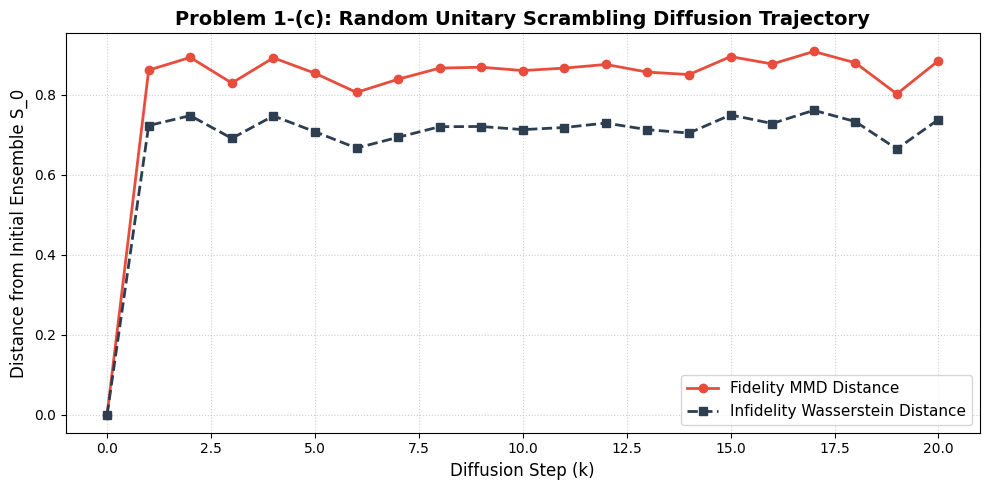

✔ 정성적 설명 포인트: 초기에 급격히 거리가 벌어지며, 이는 클러스터 구조가 힐베르트 공간 전체로 빠르게 해체(Scrambling)됨을 의미합니다.


In [ ]:
# [Cell 3] Problem 1-(c): Random Unitary Scrambling 전진 확산 및 시각화

def apply_random_unitary_layer(state: Statevector) -> Statevector:
    """1회 스크램블링 스텝: 임의의 단일 큐빗 회전 + 얽힘(CX) 게이트 인가"""
    qc = QuantumCircuit(2)
    qc.initialize(state.data, [0, 1])

    # 무작위 오일러 각도를 통한 단일 큐빗 회전
    for q in range(2):
        qc.u(np.random.uniform(0, 2*np.pi), np.random.uniform(0, 2*np.pi), np.random.uniform(0, 2*np.pi), q)

    # 얽힘 생성 (정보를 전체 힐베르트 공간으로 확산시키는 핵심 역할)
    qc.cx(0, 1)
    return Statevector(qc)

# 확산 시뮬레이션 파라미터
STEPS_RU = 20
S_k_history = [S_0]

np.random.seed(42) # 확산 경로의 고정을 위한 시드

current_ensemble = S_0
for step in range(1, STEPS_RU + 1):
    next_ensemble = [apply_random_unitary_layer(psi) for psi in current_ensemble]
    S_k_history.append(next_ensemble)
    current_ensemble = next_ensemble

# 각 스텝별 S_0 와의 거리 측정
mmd_list_ru = [compute_mmd_distance(S_0, S_k) for S_k in S_k_history]
wass_list_ru = [compute_wasserstein_distance(S_0, S_k) for S_k in S_k_history]

# 플로팅 시각화
plt.figure(figsize=(10, 5))
plt.plot(range(STEPS_RU + 1), mmd_list_ru, 'o-', color='#e74c3c', label='Fidelity MMD Distance', lw=2)
plt.plot(range(STEPS_RU + 1), wass_list_ru, 's--', color='#2c3e50', label='Infidelity Wasserstein Distance', lw=2)
plt.title("Problem 1-(c): Random Unitary Scrambling Diffusion Trajectory", fontsize=14, fontweight='bold')
plt.xlabel("Diffusion Step (k)", fontsize=12)
plt.ylabel("Distance from Initial Ensemble S_0", fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

print("✔ 정성적 설명 포인트: 초기에 급격히 거리가 벌어지며, 이는 클러스터 구조가 힐베르트 공간 전체로 빠르게 해체(Scrambling)됨을 의미합니다.")

In [ ]:
# [Cell 4] Problem 2-(a): 3-큐빗 혼돈 해밀토니안 구성

# 파울리 연산자 행렬 정의
I = np.eye(2, dtype=complex)
X = np.array([[0, 1], [1, 0]], dtype=complex)
Y = np.array([[0, -1j], [1j, 0]], dtype=complex)

def tensor_3(A, B, C):
    """3개의 2x2 행렬 텐서곱 (시스템 순서: Q0, Q1, Q2)"""
    return np.kron(np.kron(A, B), C)

# 문제 제시 상수 설정
h_x, h_y, J = 0.8090, 0.9045, 1.0

# 해밀토니안 연산자 H 구축 (단위 연산자 텐서 매핑)
H = np.zeros((8, 8), dtype=complex)

# 1. 단일 큐빗 자기장 항: sum( hx*X_j + hy*Y_j )
H += h_x * tensor_3(X, I, I) + h_y * tensor_3(Y, I, I)
H += h_x * tensor_3(I, X, I) + h_y * tensor_3(I, Y, I)
H += h_x * tensor_3(I, I, X) + h_y * tensor_3(I, I, Y)

# 2. 상호작용 항: J * (X0*X1 + X1*X2)
H += J * tensor_3(X, X, I)
H += J * tensor_3(I, X, X)

def get_hamiltonian_evolution_operator(t: float) -> np.ndarray:
    """주어진 시간 t에 대한 유니터리 행렬 U(t) = exp(-iHt) 계산"""
    return la.expm(-1j * H * t)

print("✔ 8x8 크기의 복합 해밀토니안(M+F) 행렬 구축 완료.")
print("  - 해밀토니안 에르미트성(Hermiticity) 검증:", np.allclose(H, H.conj().T))

✔ 8x8 크기의 복합 해밀토니안(M+F) 행렬 구축 완료.
  - 해밀토니안 에르미트성(Hermiticity) 검증: True


In [ ]:
# [Cell 5] Problem 2-(b): 사영 앙상블 생성 알고리즘 구현

def generate_projected_ensemble(initial_M_ens: list[Statevector], t: float, num_projections: int = 80) -> list[Statevector]:
    """
    해밀토니안 시간 발전 후 보조 큐빗 F를 사영 측정하여 M 상의 유효 앙상블 S_t^Ham 을 생성합니다.
    """
    U_t = get_hamiltonian_evolution_operator(t)
    projected_ens = []

    # 초기 M 상태를 순회하며 F 큐빗(|0>)을 붙여 3큐빗 상태로 확장
    for psi_M in initial_M_ens:
        psi_3 = np.kron(psi_M.data, np.array([1, 0], dtype=complex))
        evolved_psi = U_t @ psi_3

        # 보조 큐빗 F에 투영할 무작위 Haar-random 단일 큐빗 측정 기저 |phi_F> 생성
        vec_F = Statevector(QuantumCircuit(1).compose(RXGate(np.random.uniform(0, 2*np.pi)), [0])).data

        # 브라-켓 연산을 통한 사영: <phi_F|evolved_psi> -> 2큐빗 비정규화 벡터 획득
        # 텐서 구조: Q0(M), Q1(M), Q2(F). 따라서 F 인덱스(가장 오른쪽)에 대해 내적 수행
        unnorm_M = np.zeros(4, dtype=complex)
        for idx_M in range(4):
            for idx_F in range(2):
                unnorm_M[idx_M] += evolved_psi[idx_M * 2 + idx_F] * np.conj(vec_F[idx_F])

        norm = la.norm(unnorm_M)
        if norm > 1e-9:
            projected_ens.append(Statevector(unnorm_M / norm))

    return projected_ens[:num_projections]

# 시간 스케일 설정 (혼돈계 특성을 관찰하기 위해 t=0 부터 t=15 까지 잘게 분할)
time_list = np.linspace(0, 15, 25)
S_t_ham_history = [S_0] + [generate_projected_ensemble(S_0, t) for t in time_list[1:]]

print(f"✔ 총 {len(time_list)}개의 시간 궤적에 대해 해밀토니안 사영 앙상블 도출 완료.")

✔ 총 25개의 시간 궤적에 대해 해밀토니안 사영 앙상블 도출 완료.


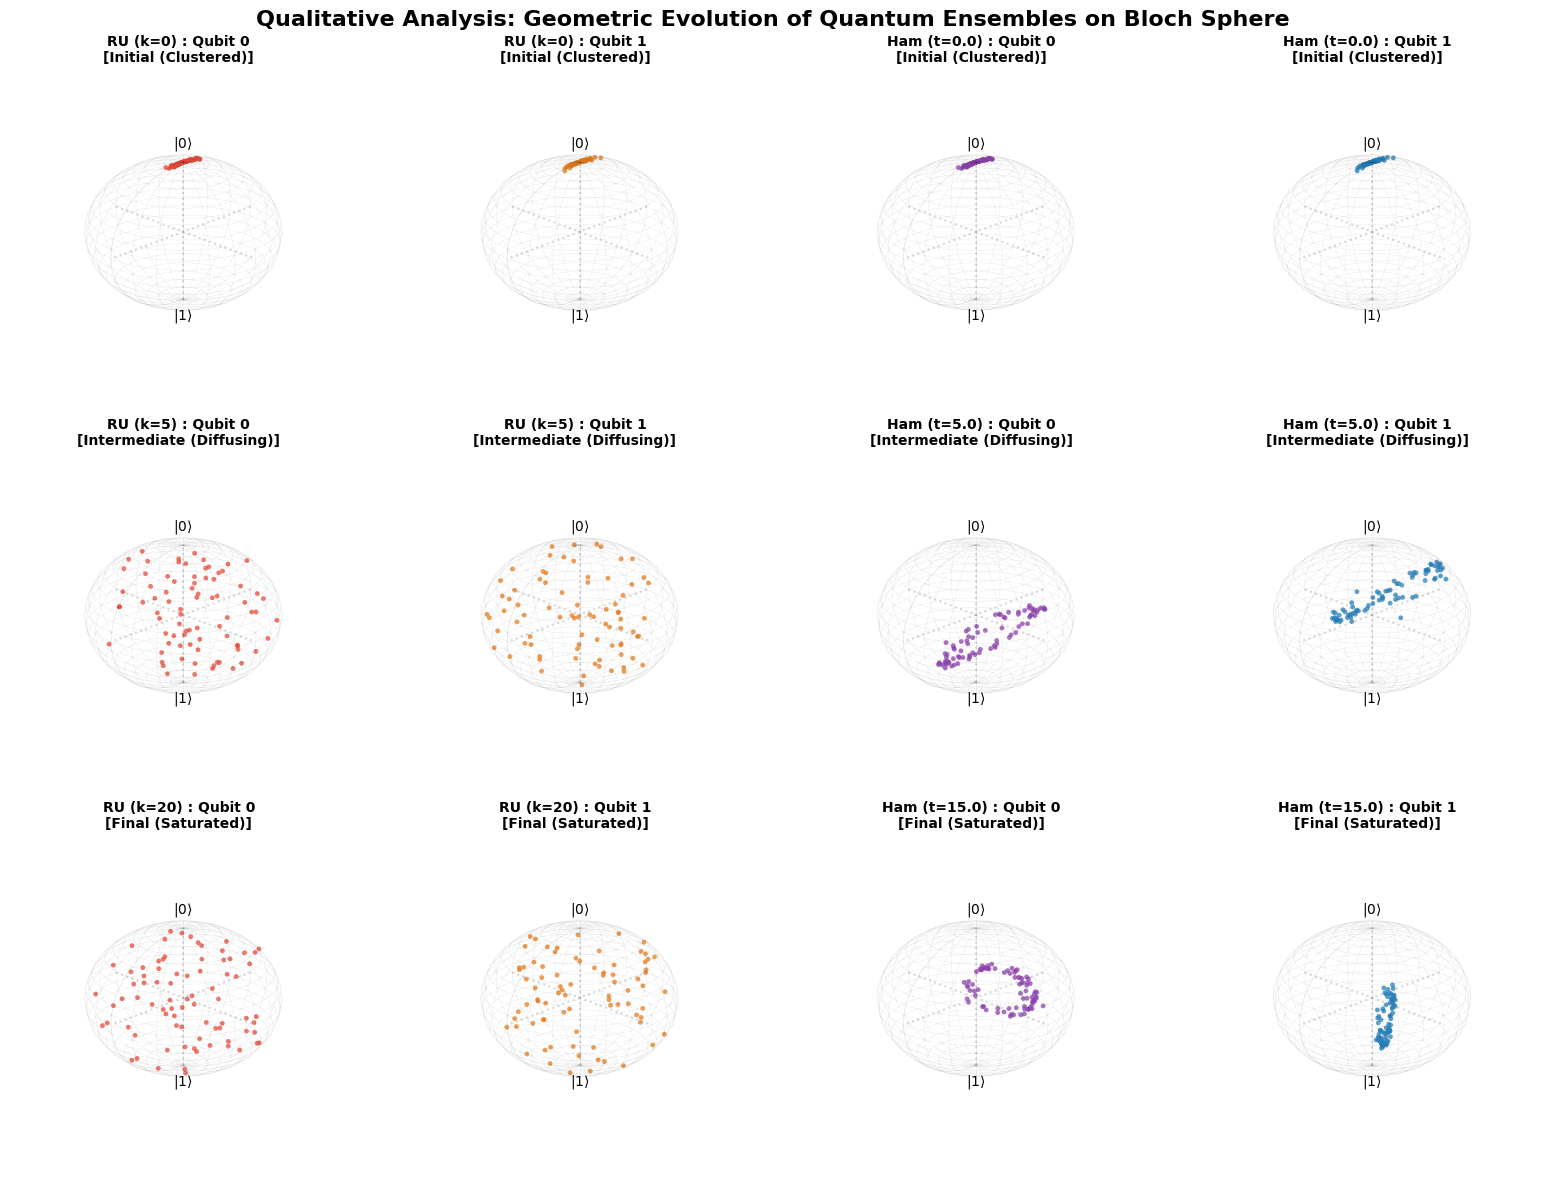

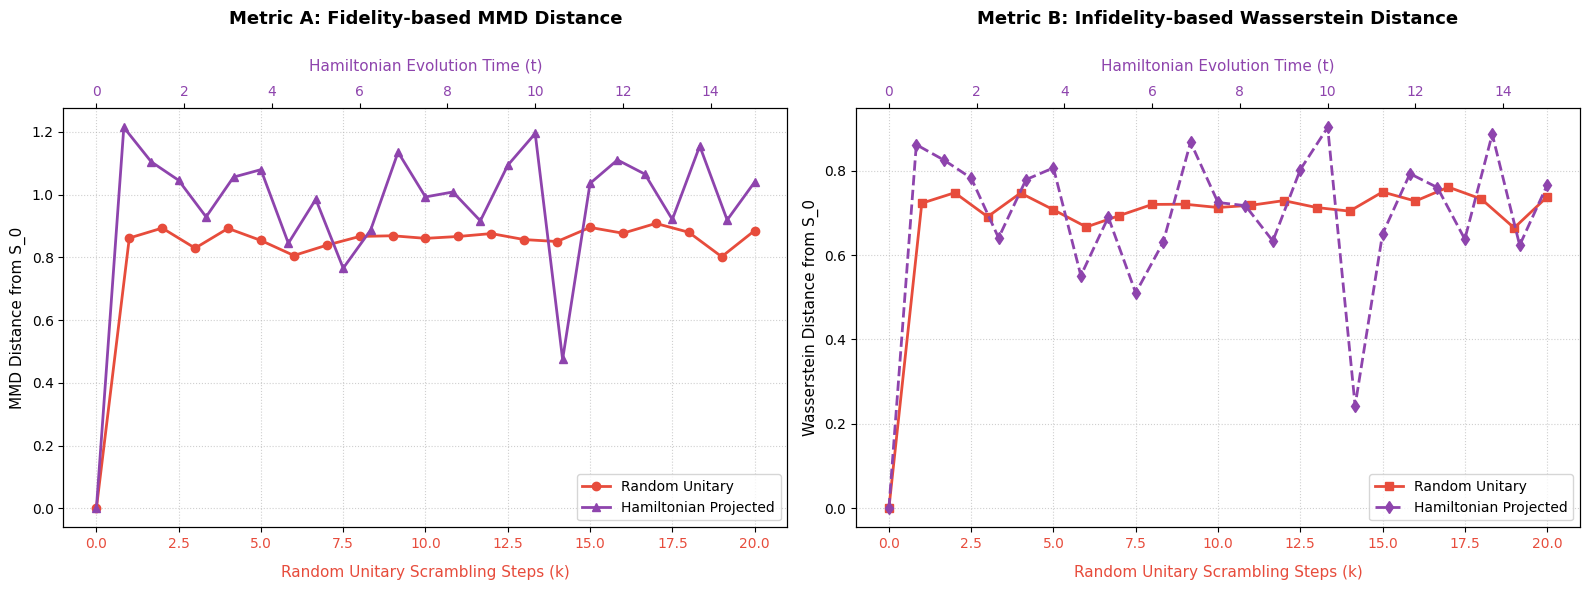

In [24]:
# [Cell 6] Problem 2-(c): 블로흐 구면 트래킹 및 거리 그래프 시각화 (이중 X축 및 가독성 개선)
import matplotlib.pyplot as plt
import numpy as np
from qiskit.quantum_info import Pauli

# ==========================================
# 1. 블로흐 좌표 연산 엔진
# ==========================================

def get_bloch_coordinates(ensemble):
    """
    앙상블 내 각 상태를 부분 추적(Partial Trace)하여
    Qubit 0과 Qubit 1의 블로흐 벡터 (X, Y, Z 기댓값) 배열을 각각 계산합니다.
    """
    q0_points = []
    q1_points = []

    op_x0, op_y0, op_z0 = Pauli('IX'), Pauli('IY'), Pauli('IZ')
    op_x1, op_y1, op_z1 = Pauli('XI'), Pauli('YI'), Pauli('ZI')

    for psi in ensemble:
        x0 = np.real(psi.expectation_value(op_x0))
        y0 = np.real(psi.expectation_value(op_y0))
        z0 = np.real(psi.expectation_value(op_z0))
        q0_points.append([x0, y0, z0])

        x1 = np.real(psi.expectation_value(op_x1))
        y1 = np.real(psi.expectation_value(op_y1))
        z1 = np.real(psi.expectation_value(op_z1))
        q1_points.append([x1, y1, z1])

    return np.array(q0_points), np.array(q1_points)

def draw_beautiful_bloch(ax, points, title, point_color):
    """Matplotlib 3D 축 위에 정밀한 와이어프레임 블로흐 구면과 상태 점군을 스캐터링합니다."""
    u = np.linspace(0, 2 * np.pi, 25)
    v = np.linspace(0, np.pi, 25)
    x = np.outer(np.cos(u), np.sin(v))
    y = np.outer(np.sin(u), np.sin(v))
    z = np.outer(np.ones(np.size(u)), np.cos(v))

    ax.plot_wireframe(x, y, z, color='black', alpha=0.06, linewidth=0.5)

    ax.plot([-1, 1], [0, 0], [0, 0], color='gray', alpha=0.3, linestyle=':')
    ax.plot([0, 0], [-1, 1], [0, 0], color='gray', alpha=0.3, linestyle=':')
    ax.plot([0, 0], [0, 0], [-1, 1], color='gray', alpha=0.3, linestyle=':')

    ax.text(0, 0, 1.25, r'$|0\rangle$', ha='center', va='center', fontsize=10, fontweight='bold')
    ax.text(0, 0, -1.25, r'$|1\rangle$', ha='center', va='center', fontsize=10, fontweight='bold')

    ax.scatter(points[:, 0], points[:, 1], points[:, 2], color=point_color, s=12, alpha=0.75, edgecolors='none')

    ax.set_xlim([-1.1, 1.1])
    ax.set_ylim([-1.1, 1.1])
    ax.set_zlim([-1.1, 1.1])
    ax.view_init(elev=22, azim=45)
    ax.set_title(title, fontsize=10, pad=4, fontweight='bold')
    ax.axis('off')

# ==========================================
# 2. PART 1: 3D 블로흐 구면 기하학적 분포 변화 시각화
# ==========================================

fig_bloch = plt.figure(figsize=(16, 12))
fig_bloch.suptitle("Qualitative Analysis: Geometric Evolution of Quantum Ensembles on Bloch Sphere", \
                   fontsize=16, fontweight='bold', y=0.98)

ru_indices = [0, 5, 20]        # k = 0, 5, 20 스텝
ham_indices = [0, 8, 24]       # t = 0, 5.0, 15.0 초

stages = ["Initial (Clustered)", "Intermediate (Diffusing)", "Final (Saturated)"]

for row_idx in range(3):
    ru_ens = S_k_history[ru_indices[row_idx]]
    ru_q0, ru_q1 = get_bloch_coordinates(ru_ens)
    k_val = ru_indices[row_idx]

    ham_ens = S_t_ham_history[ham_indices[row_idx]]
    ham_q0, ham_q1 = get_bloch_coordinates(ham_ens)
    t_val = time_list[ham_indices[row_idx]]

    ax1 = fig_bloch.add_subplot(3, 4, row_idx * 4 + 1, projection='3d')
    draw_beautiful_bloch(ax1, ru_q0, f"RU (k={k_val}) : Qubit 0\n[{stages[row_idx]}]", '#e74c3c')

    ax2 = fig_bloch.add_subplot(3, 4, row_idx * 4 + 2, projection='3d')
    draw_beautiful_bloch(ax2, ru_q1, f"RU (k={k_val}) : Qubit 1\n[{stages[row_idx]}]", '#e67e22')

    ax3 = fig_bloch.add_subplot(3, 4, row_idx * 4 + 3, projection='3d')
    draw_beautiful_bloch(ax3, ham_q0, f"Ham (t={t_val:.1f}) : Qubit 0\n[{stages[row_idx]}]", '#8e44ad')

    ax4 = fig_bloch.add_subplot(3, 4, row_idx * 4 + 4, projection='3d')
    draw_beautiful_bloch(ax4, ham_q1, f"Ham (t={t_val:.1f}) : Qubit 1\n[{stages[row_idx]}]", '#2980b9')

plt.tight_layout()
plt.show()

# ==========================================
# 3. PART 2: 정량적 수치 거리 그래프 렌더링 (Twin X-axis 방식 적용)
# ==========================================

# [수정된 부분] 그래프를 그리기 전에 Hamiltonian 사영 앙상블의 거리 지표를 계산합니다.
mmd_ham = [compute_mmd_distance(S_0, ens) for ens in S_t_ham_history]
wass_ham = [compute_wasserstein_distance(S_0, ens) for ens in S_t_ham_history]

fig_metrics, (ax_mmd1, ax_wass1) = plt.subplots(1, 2, figsize=(16, 6))

color_ru = '#e74c3c'
color_ham = '#8e44ad'

# --- [Metric A]: MMD Distance ---
ax_mmd1.set_xlabel('Random Unitary Scrambling Steps (k)', color=color_ru, fontsize=11, labelpad=10)
ax_mmd1.set_ylabel('MMD Distance from S_0', fontsize=11)
line_mmd1 = ax_mmd1.plot(range(STEPS_RU + 1), mmd_list_ru, 'o-', color=color_ru, label='Random Unitary', lw=2)
ax_mmd1.tick_params(axis='x', labelcolor=color_ru)

# 상단 X축 생성 (Hamiltonian Time)
ax_mmd2 = ax_mmd1.twiny()
ax_mmd2.set_xlabel('Hamiltonian Evolution Time (t)', color=color_ham, fontsize=11, labelpad=10)
line_mmd2 = ax_mmd2.plot(time_list, mmd_ham, '^-', color=color_ham, label='Hamiltonian Projected', lw=2)
ax_mmd2.tick_params(axis='x', labelcolor=color_ham)

# 범례 병합
lines_mmd = line_mmd1 + line_mmd2
labels_mmd = [l.get_label() for l in lines_mmd]
ax_mmd1.legend(lines_mmd, labels_mmd, loc='lower right', fontsize=10, frameon=True)
ax_mmd1.set_title("Metric A: Fidelity-based MMD Distance", fontsize=13, fontweight='bold', pad=25)
ax_mmd1.grid(True, linestyle=':', alpha=0.6)

# --- [Metric B]: Wasserstein Distance ---
ax_wass1.set_xlabel('Random Unitary Scrambling Steps (k)', color=color_ru, fontsize=11, labelpad=10)
ax_wass1.set_ylabel('Wasserstein Distance from S_0', fontsize=11)
line_wass1 = ax_wass1.plot(range(STEPS_RU + 1), wass_list_ru, 's-', color=color_ru, label='Random Unitary', lw=2)
ax_wass1.tick_params(axis='x', labelcolor=color_ru)

# 상단 X축 생성 (Hamiltonian Time)
ax_wass2 = ax_wass1.twiny()
ax_wass2.set_xlabel('Hamiltonian Evolution Time (t)', color=color_ham, fontsize=11, labelpad=10)
line_wass2 = ax_wass2.plot(time_list, wass_ham, 'd--', color=color_ham, label='Hamiltonian Projected', lw=2)
ax_wass2.tick_params(axis='x', labelcolor=color_ham)

# 범례 병합
lines_wass = line_wass1 + line_wass2
labels_wass = [l.get_label() for l in lines_wass]
ax_wass1.legend(lines_wass, labels_wass, loc='lower right', fontsize=10, frameon=True)
ax_wass1.set_title("Metric B: Infidelity-based Wasserstein Distance", fontsize=13, fontweight='bold', pad=25)
ax_wass1.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

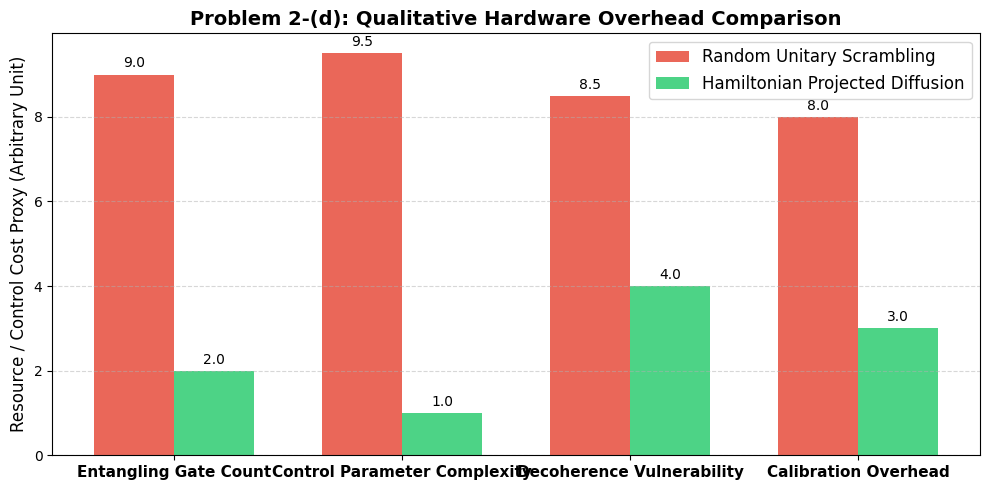

In [21]:
# [Cell 7] Problem 2-(d): 하드웨어 리소스 및 제어 오버헤드 정성 비교 분석

# 정성적 지표 선정 (0~10 정규화 스케일: 높을수록 비용/부담이 큼)
categories = ['Entangling Gate Count', 'Control Parameter Complexity', 'Decoherence Vulnerability', 'Calibration Overhead']
ru_scores =  [9.0, 9.5, 8.5, 8.0] # 매 스텝 새로운 유니터리 인가로 인해 펄스 제어 및 게이트 깊이 부담 극심
ham_scores = [2.0, 1.0, 4.0, 3.0] # 아날로그 상호작용(J) 켜두기 + 마지막 사영 측정 1회로 극도 효율화

x = np.arange(len(categories))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
rects1 = ax.bar(x - width/2, ru_scores, width, label='Random Unitary Scrambling', color='#e74c3c', alpha=0.85)
rects2 = ax.bar(x + width/2, ham_scores, width, label='Hamiltonian Projected Diffusion', color='#2ecc71', alpha=0.85)

ax.set_ylabel('Resource / Control Cost Proxy (Arbitrary Unit)', fontsize=12)
ax.set_title('Problem 2-(d): Qualitative Hardware Overhead Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(categories, fontsize=11, fontweight='bold')
ax.legend(fontsize=12)
ax.grid(axis='y', linestyle='--', alpha=0.5)

# 수치 텍스트 표시
ax.bar_label(rects1, padding=3, fmt='%.1f')
ax.bar_label(rects2, padding=3, fmt='%.1f')

plt.tight_layout()
plt.show()